# **Importing necessary libraries**

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# **Importing and loading the dataset**

In [122]:
laptop_price_dataset = pd.read_csv("laptop_prices.csv")
laptop_price_dataset.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


# **Number of unique values in each observations**

In [123]:
company_names = laptop_price_dataset.nunique()
company_names

,0
Company,19
Product,618
TypeName,6
Inches,18
Ram,9
OS,9
Weight,171
Price_euros,791
Screen,4
ScreenW,13


# **Dropping or deleting unnecessary columns**

In [124]:
laptop_price_dataset = laptop_price_dataset.drop(columns = ["TypeName", "ScreenW", "ScreenH"])

print("Improved Dataset")
print()
laptop_price_dataset.head()

Improved Dataset



,Company,Product,Inches,Ram,OS,Weight,Price_euros,Screen,Touchscreen,IPSpanel,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,13.3,8,macOS,1.37,1339.69,Standard,No,Yes,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,13.3,8,macOS,1.34,898.94,Standard,No,No,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,15.6,8,No OS,1.86,575.00,Full HD,No,No,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,15.4,16,macOS,1.83,2537.45,Standard,No,Yes,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,13.3,8,macOS,1.37,1803.60,Standard,No,Yes,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


# **Information about the dataset**

In [125]:
print(laptop_price_dataset.describe())
print()
print()
print()
print(laptop_price_dataset.info())

            Inches          Ram       Weight  Price_euros     CPU_freq  \
count  1275.000000  1275.000000  1275.000000  1275.000000  1275.000000   
mean     15.022902     8.440784     2.040525  1134.969059     2.302980   
std       1.429470     5.097809     0.669196   700.752504     0.503846   
min      10.100000     2.000000     0.690000   174.000000     0.900000   
25%      14.000000     4.000000     1.500000   609.000000     2.000000   
50%      15.600000     8.000000     2.040000   989.000000     2.500000   
75%      15.600000     8.000000     2.310000  1496.500000     2.700000   
max      18.400000    64.000000     4.700000  6099.000000     3.600000   

       PrimaryStorage  SecondaryStorage  
count     1275.000000       1275.000000  
mean       444.517647        176.069020  
std        365.537726        415.960655  
min          8.000000          0.000000  
25%        256.000000          0.000000  
50%        256.000000          0.000000  
75%        512.000000          0.000000

# **Top companies by price (in Euros)**

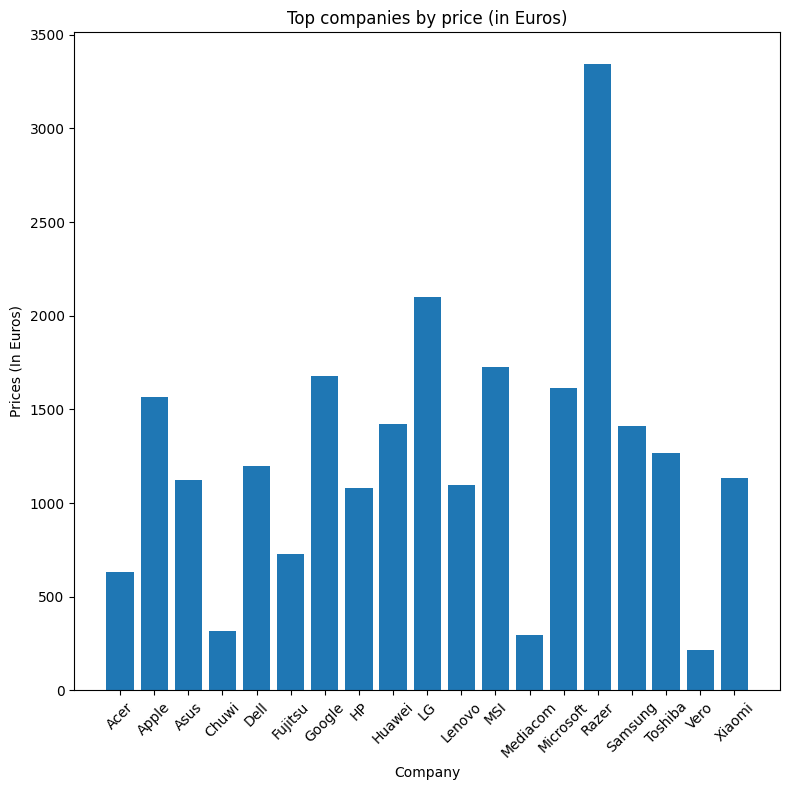

In [126]:
top_company_prices = laptop_price_dataset.groupby("Company")["Price_euros"].mean()

plt.figure(figsize = (8, 8))
plt.bar(top_company_prices.index, top_company_prices.values)
plt.xlabel("Company")
plt.ylabel("Prices (In Euros)")
plt.title("Top companies by price (in Euros)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# **Top products by price (in Euros)**

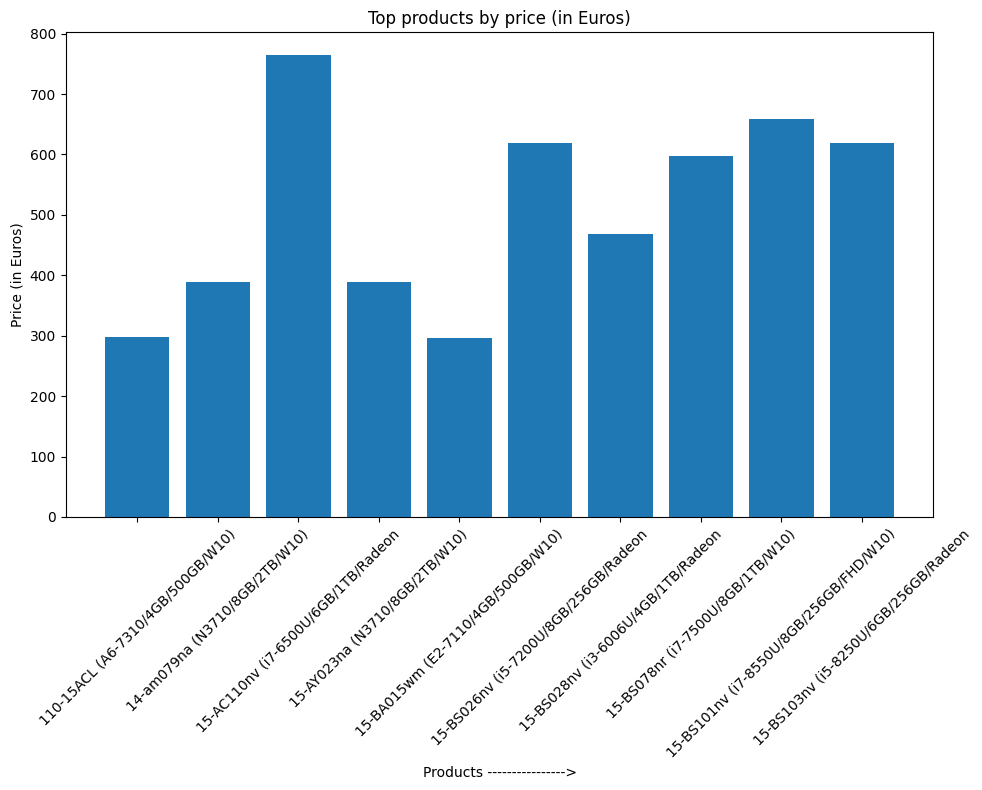

In [127]:
top_product_prices = laptop_price_dataset.groupby("Product")["Price_euros"].mean()

plt.figure(figsize = (10, 8))
plt.bar(top_product_prices.head(10).index, top_product_prices.head(10).values)
plt.xlabel("Products ---------------->")
plt.ylabel("Price (in Euros)")
plt.title("Top products by price (in Euros)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# **Splitting the dataset into training and testing set**

In [128]:
X = laptop_price_dataset[['Company', 'Product', 'Inches', 'Ram', 'OS', 'Weight', 'Screen', 'Touchscreen', 'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model', 'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_company', 'GPU_model']]
y = laptop_price_dataset[ 'Price_euros']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

# **Hot Encoding the categorical columns using Preprocessing**

In [129]:
categorical_columns = ["Company", "Product", "OS", "Screen", "Touchscreen", "IPSpanel", "RetinaDisplay", "CPU_company", "CPU_model", "PrimaryStorageType", "SecondaryStorageType", "GPU_company", "GPU_model"]

preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_columns
        )
    ],
    remainder = "passthrough"
)

linear_regression_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regression", LinearRegression())
    ]
)

# **Training the Linear Regression Model using the training set**

In [130]:
linear_regression_model.fit(X_train, y_train)
y_prediction = linear_regression_model.predict(X_test)
print(y_prediction)

[ 482.49936472  667.70318799 1604.00958508 1164.45734908 1885.52381064
  887.08013607 1236.11430077  301.40557986 2414.15179097  499.79346462
 1329.49413164  818.5394541  1298.83148134 1657.20370368 2569.82614066
  759.68588322 1066.05801834 1163.37646037 1683.04681629 2131.85569547
  992.8415275   618.42955769 1754.55420753 1959.87099217  749.8700253
 1819.52583223  984.83129758  532.81430751  812.77798302  979.39543805
  734.62261364  485.97878318 1004.81768376  305.47225678 1052.82169653
  781.0123479   972.66802761  435.25923584  902.69231234 1003.82600356
 1314.31225129  244.90915893  997.481308   1388.35004955  731.31816347
 1305.74451567 1604.5872516   741.66446244 1246.72302458  799.32877528
 1016.05384339  509.22500437 2531.55134991  493.24951946  641.21860095
 1662.04478933 1135.04686266 1571.28634263 1191.11412191  780.17892997
  937.09421013  606.05376437 2028.15541615  736.97270807  719.20077667
  448.56789921  653.4549189   848.42255054  438.98834897  718.83361422
 1340.4

# **Evaluating the Linear Regression Model**

In [131]:
mae = mean_absolute_error(y_test, y_prediction)
mse = mean_squared_error(y_test, y_prediction)
r2 = r2_score(y_test, y_prediction)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared score: {r2}")
print()
print(f"Model prediction accuracy: {r2 * 100:.4f}%")

Mean Absolute Error: 182.8132583101985
Mean Squared Error: 64052.267405929924
R-squared score: 0.8709506366677569

Model prediction accuracy: 87.0951%


# **Predicting the laptop prices using unknown data**

In [132]:
company = input("Enter Company (e.g., Dell, HP, Apple): ")
product = input("Enter Product (e.g., Inspiron, MacBook Air): ")
inches = float(input("Enter Screen Size (in inches): "))
ram = int(input("Enter RAM (in GB): "))
os = input("Enter Operating System (Windows, macOS, Linux): ")
weight = float(input("Enter Weight (in kg): "))
screen = input("Enter Screen Resolution (e.g., Full HD, Quad HD, 4K): ")
touchscreen_input = int(input("Touchscreen? (1 = Yes, 0 = No): "))
ipspanel_input = int(input("IPS Panel? (1 = Yes, 0 = No): "))
retinadisplay_input = int(input("Retina Display? (1 = Yes, 0 = No): "))
cpu_company = input("Enter CPU Company (Intel/AMD): ")
cpu_freq = float(input("Enter CPU Frequency (GHz): "))
cpu_model = input("Enter CPU Model (e.g., Core i5, Ryzen 7): ")
primary_storage = int(input("Enter Primary Storage Size (GB): "))
secondary_storage = int(input("Enter Secondary Storage Size (GB, 0 if none): "))
primary_storage_type = input("Enter Primary Storage Type (SSD/HDD): ")
secondary_storage_type = input("Enter Secondary Storage Type (SSD/HDD/None): ")
gpu_company = input("Enter GPU Company (Intel/NVIDIA/AMD): ")
gpu_model = input("Enter GPU Model (e.g., UHD 620, GTX 1650): ")

# Convert integer inputs to 'Yes'/'No' strings to match training data format
touchscreen = 'Yes' if touchscreen_input == 1 else 'No'
ipspanel = 'Yes' if ipspanel_input == 1 else 'No'
retinadisplay = 'Yes' if retinadisplay_input == 1 else 'No'

input_data = pd.DataFrame({
    'Company': [company],
    'Product': [product],
    'Inches': [inches],
    'Ram': [ram],
    'OS': [os],
    'Weight': [weight],
    'Screen': [screen],
    'Touchscreen': [touchscreen],
    'IPSpanel': [ipspanel],
    'RetinaDisplay': [retinadisplay],
    'CPU_company': [cpu_company],
    'CPU_freq': [cpu_freq],
    'CPU_model': [cpu_model],
    'PrimaryStorage': [primary_storage],
    'SecondaryStorage': [secondary_storage],
    'PrimaryStorageType': [primary_storage_type],
    'SecondaryStorageType': [secondary_storage_type],
    'GPU_company': [gpu_company],
    'GPU_model': [gpu_model]
})

predicted_price = linear_regression_model.predict(input_data)
print(f"Predicted Laptop Price: €{predicted_price[0]:.2f}")

Enter Company (e.g., Dell, HP, Apple): Dell
Enter Product (e.g., Inspiron, MacBook Air): Inspiron 15
Enter Screen Size (in inches): 15.6
Enter RAM (in GB): 8
Enter Operating System (Windows, macOS, Linux): Windows
Enter Weight (in kg): 1.85
Enter Screen Resolution (e.g., Full HD, Quad HD, 4K): Full HD
Touchscreen? (1 = Yes, 0 = No): 0
IPS Panel? (1 = Yes, 0 = No): 1
Retina Display? (1 = Yes, 0 = No): 0
Enter CPU Company (Intel/AMD): Intel
Enter CPU Frequency (GHz): 2.5
Enter CPU Model (e.g., Core i5, Ryzen 7): Core i5
Enter Primary Storage Size (GB): 512
Enter Secondary Storage Size (GB, 0 if none): 0
Enter Primary Storage Type (SSD/HDD): SSD
Enter Secondary Storage Type (SSD/HDD/None): None
Enter GPU Company (Intel/NVIDIA/AMD): Intel
Enter GPU Model (e.g., UHD 620, GTX 1650): UHD Graphics 620
Predicted Laptop Price: €1353.28
